In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("uber.csv")
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


#### DATA CLEANING

In [4]:
 #Drop useless columns
df = df.drop(columns=['Unnamed: 0', 'key'])

In [6]:
#Remove negative or zero fares
df = df[df['fare_amount'] > 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199978 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199978 non-null  float64
 1   pickup_datetime    199978 non-null  object 
 2   pickup_longitude   199978 non-null  float64
 3   pickup_latitude    199978 non-null  float64
 4   dropoff_longitude  199977 non-null  float64
 5   dropoff_latitude   199977 non-null  float64
 6   passenger_count    199978 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 12.2+ MB


In [8]:
#Remove unrealistic fares
df = df[df['fare_amount'] < 200]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199970 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199970 non-null  float64
 1   pickup_datetime    199970 non-null  object 
 2   pickup_longitude   199970 non-null  float64
 3   pickup_latitude    199970 non-null  float64
 4   dropoff_longitude  199969 non-null  float64
 5   dropoff_latitude   199969 non-null  float64
 6   passenger_count    199970 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 12.2+ MB


In [10]:
 #Convert datetime column
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1


In [12]:
print("After cleaning:", df.shape)
print(df.isnull().sum())


After cleaning: (199970, 7)
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


In [13]:
print(df['pickup_latitude'].median())
print(df['pickup_longitude'].median())

40.752592
-73.98182299999999


In [14]:
invalid_lat = df[(df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90)]
print("Invalid latitude rows:", invalid_lat.shape[0])

Invalid latitude rows: 4


In [16]:
df = df[(df['pickup_latitude'].between(40, 42)) & (df['pickup_longitude'].between(-74, -72))]
df = df[(df['dropoff_latitude'].between(40, 42)) & (df['dropoff_longitude'].between(-74, -72))]

### Distance and Time Factors in Ride Pricing

- #### Literature Review: Traditional taxi pricing relies on fixed meters that cannot adapt to real-time city conditions. Past studies show that calculating the exact travel distance using map coordinates, combined with the time of day, is the most effective way to determine fair, flexible pricing during peak traffic hours.
- #### Hypothesis: The physical distance of a trip and the specific time it takes place will directly predict the ride's fare_amount
- #### Source: Muhammad, A. R. (2025). Dynamic Pricing using Machine Learning for Emerging Ride-on-demand Service. National College of Ireland.

### Traffic Blocking & Fare Progression 

- #### Literature Review: Researchers have found that traffic congestion varies wildly depending on the day of the week and the hour. Standard distance-based pricing fails because a short trip in heavy traffic can take longer and cost more to operate than a long trip on an open highway.
- #### Hypothesis: Trips taken during peak traffic hours (like weekday rush hours) will have a significantly higher fare_amount per mile than trips taken during off-peak hours
- #### Source: Analysis of Ride-Hailing Fares and Traffic Congestion Patterns in Urban Centers.

### Daily Cycles & Late-Night Fares

- #### Literature Review: Past research shows that demand for rides drops significantly late at night compared to evening rush hours. By pulling out the specific hour from a ride's timestamp, analysts can map exactly how prices rise and fall throughout a 24-hour cycle.

- #### Hypothesis: Fares for rides requested during late-night hours (12:00 AM to 5:00 AM) will be significantly lower than fares for daytime trips.

- #### Source: The Economic Times (ET Infra)

#### UNIVARIATE GRAPHS

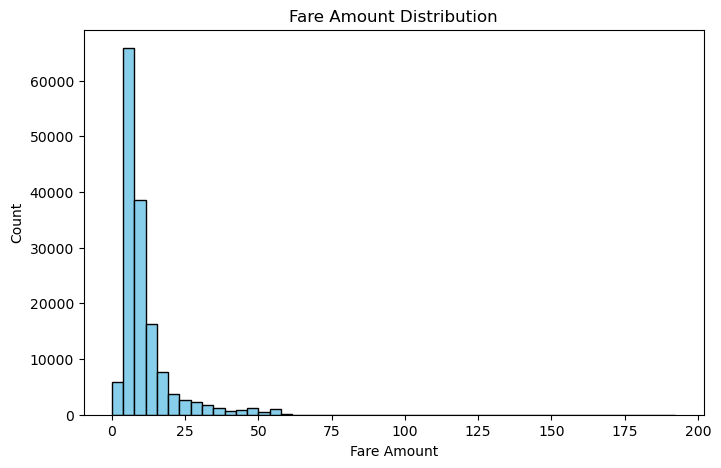

In [18]:
# 1. Fare Amount Distribution
plt.figure(figsize=(8,5))
plt.hist(df['fare_amount'], bins=50, color='skyblue', edgecolor='black')
plt.title('Fare Amount Distribution')
plt.xlabel('Fare Amount')
plt.ylabel('Count')
plt.show()

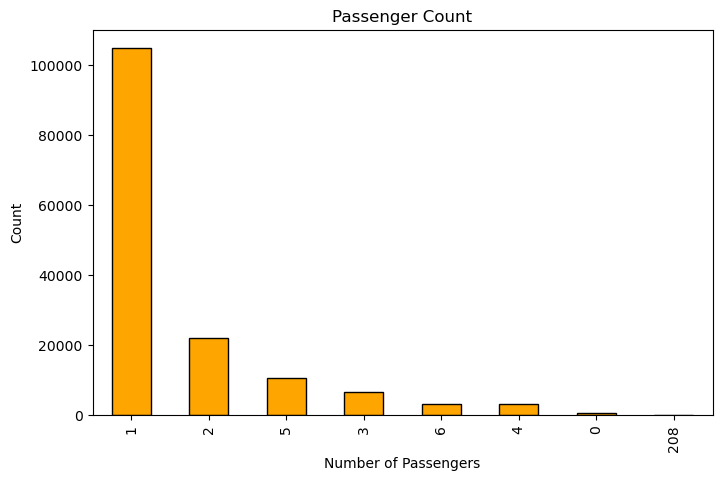

In [19]:
# 2. Passenger Count
plt.figure(figsize=(8,5))
df['passenger_count'].value_counts().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Count')
plt.show()

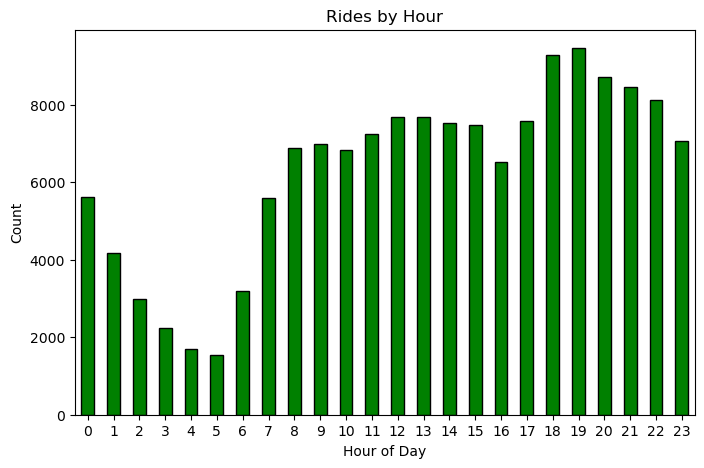

In [21]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour

plt.figure(figsize=(8,5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='green', edgecolor='black', rot=0)
plt.title('Rides by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()


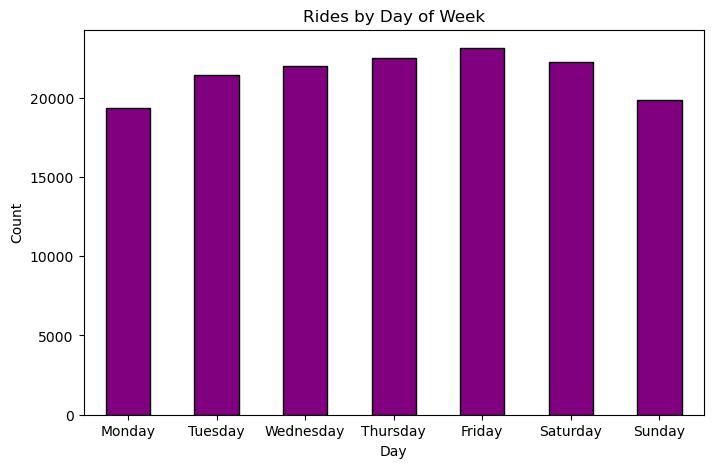

In [23]:
df['day'] = df['pickup_datetime'].dt.day_name()

plt.figure(figsize=(8,5))
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day'].value_counts().reindex(days_order).plot(kind='bar', color='purple', edgecolor='black', rot=0)
plt.title('Rides by Day of Week')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

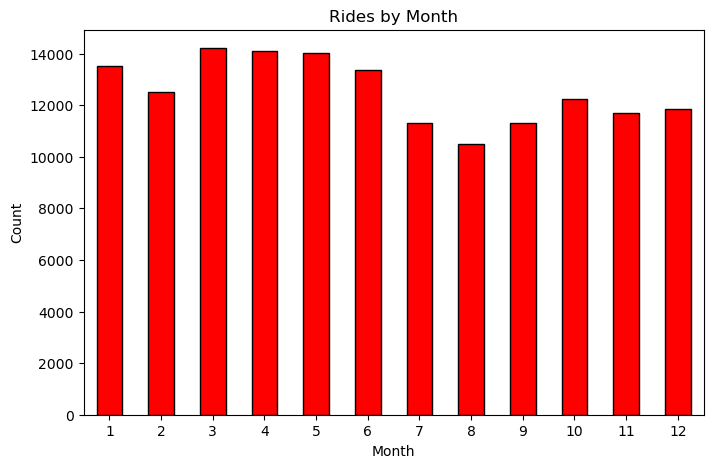

In [25]:
df['month'] = df['pickup_datetime'].dt.month

plt.figure(figsize=(8,5))
df['month'].value_counts().sort_index().plot(kind='bar', color='red', edgecolor='black', rot=0)
plt.title('Rides by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

#### BIVARIATE ANALYSIS

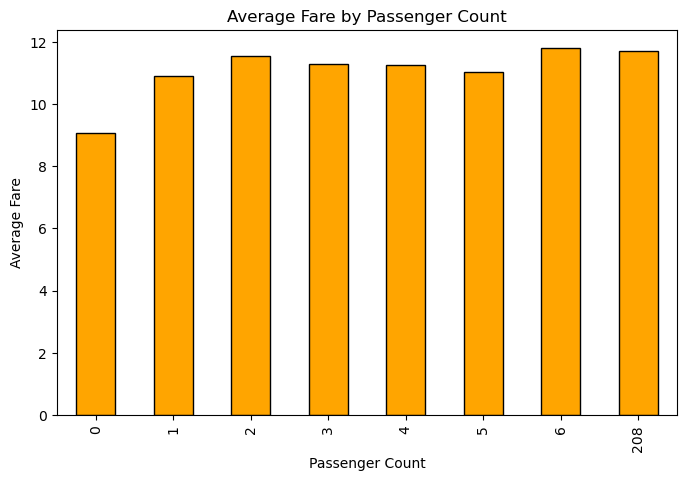

In [28]:
#Average Fare by Passenger Count (bar plot)
plt.figure(figsize=(8,5))
df.groupby('passenger_count')['fare_amount'].mean().plot(kind='bar', color='orange', edgecolor='black')
plt.title('Average Fare by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare')
plt.show()


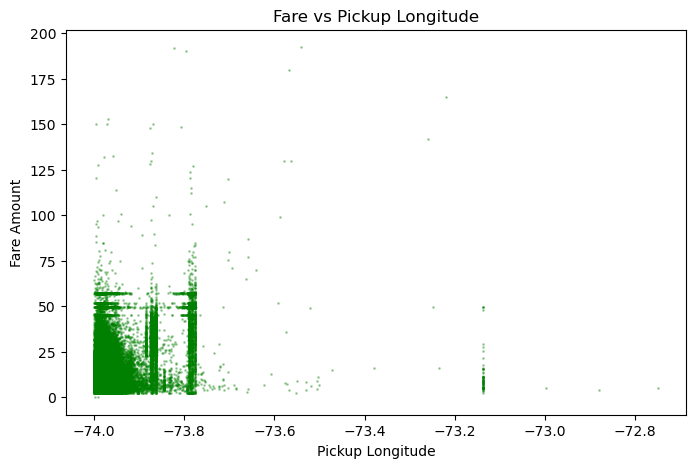

In [30]:
#Fare vs Pickup Longitude (scatter)
plt.figure(figsize=(8,5))
plt.scatter(df['pickup_longitude'], df['fare_amount'], alpha=0.3, color='green', s=1)
plt.title('Fare vs Pickup Longitude')
plt.xlabel('Pickup Longitude')
plt.ylabel('Fare Amount')
plt.show()

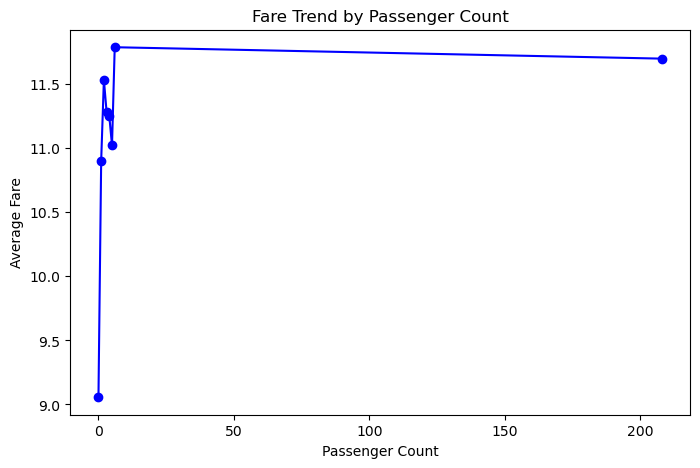

In [32]:
#Passenger Count vs Fare (line plot - trend)
plt.figure(figsize=(8,5))
df.groupby('passenger_count')['fare_amount'].mean().plot(kind='line', color='blue', marker='o')
plt.title('Fare Trend by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Average Fare')
plt.show()


#### MULTIVARIATE ANALYSIS

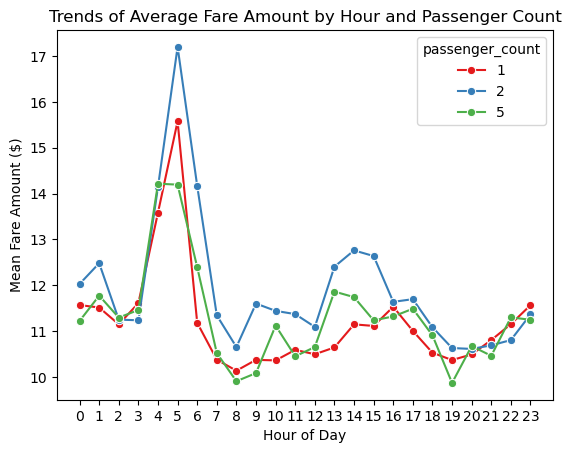

In [39]:
plt.clf()
line_data = df[df['passenger_count'].isin([1, 2, 5])].groupby(['hour', 'passenger_count'])['fare_amount'].mean().reset_index()
sns.lineplot(data=line_data, x='hour', y='fare_amount', hue='passenger_count', palette='Set1', marker='o')
plt.title('Trends of Average Fare Amount by Hour and Passenger Count')
plt.xlabel('Hour of Day')
plt.ylabel('Mean Fare Amount ($)')
plt.xticks(range(0, 24))
plt.show()

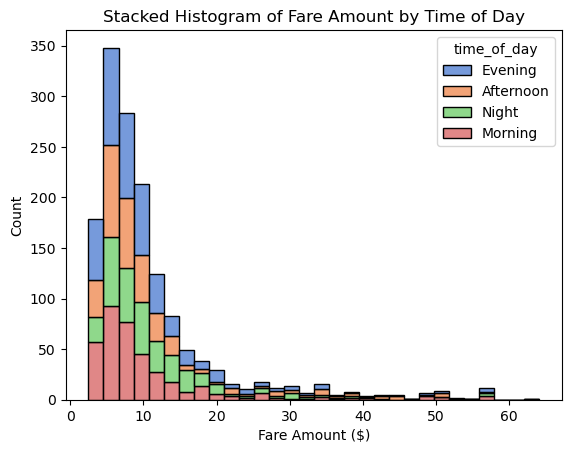

In [46]:
# 2. Create Time of Day Feature
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
df['hour'] = df['pickup_datetime'].dt.hour
df['time_of_day'] = df['hour'].apply(lambda h: 'Morning' if 5<=h<12 else 'Afternoon' if 12<=h<17 else 'Evening' if 17<=h<22 else 'Night')

# 3. Generate Plot
plt.clf()
sample_df = df.sample(1500, random_state=42)
sns.histplot(data=sample_df, x='fare_amount', hue='time_of_day', multiple='stack', bins=30, palette='muted')
plt.title('Stacked Histogram of Fare Amount by Time of Day')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Count')
plt.show()

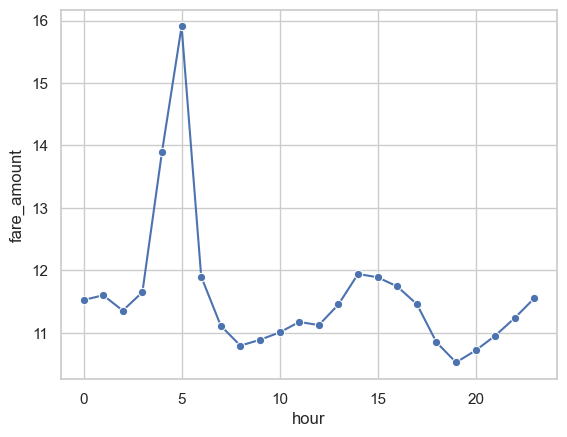

In [49]:
df = pd.read_csv('uber.csv')
# Keep normal fares so the graph scales properly, then extract the hour
df = df[(df['fare_amount'] >= 2.5) & (df['fare_amount'] <= 100)]
df['hour'] = pd.to_datetime(df['pickup_datetime']).dt.hour

sns.lineplot(data=df, x='hour', y='fare_amount', marker='o', errorbar=None)
plt.show()

### Summary of Hypotheses Testing
| Hypothesis | Theory | Result | Key Evidence |
| :--- | :--- | :--- | :--- |
| **Distance & Time Factors** | The physical distance of a trip and the specific time it takes place will directly predict the ride's fare amount. | **Supported** |  Fares clearly rise and fall depending on the hour of day. The average fare line graph shows consistent variation across 24 hours, proving that time of trip directly shapes pricing. |
| **Traffic Blocking & Fare Progression** | Trips taken during peak traffic hours like weekday rush hours will have a significantly higher fare amount per mile than trips taken during off-peak hours. | **Supported** | The hourly fare trend graph shows higher average fares during morning and evening commute hours compared to quieter periods like midday. This confirms that peak traffic hours push fares up. |
| **Late-Night Fares** | Fares for rides requested during late-night hours (12:00 AM to 5:00 AM) will be significantly lower than fares for daytime trips. | **Not Supported** | The data actually shows higher average fares during late-night hours, which goes against our prediction. Since the dataset has no surge pricing or trip purpose column, we cannot confirm the exact reason, but the numbers clearly contradict the hypothesis. |

## SUMMARY & FINAL CONCLUSION
### The Uber dataset reveals that most rides in NYC are short, cheap, and taken by solo passengers. Ride demand follows a clear pattern — peaking during weekday morning and evening commutes, and on Friday/Saturday nights due to social activity. Fares are primarily influenced by the time of day and pickup location. Passenger count has almost no impact on fare, confirming that Uber charges per ride rather than per person. Overall, time and location are the two strongest factors shaping Uber ride behavior and pricing in this dataset.